In [90]:
include("CRD_STA.jl")
include("Fun.jl")
using NonlinearEigenproblems
using DelimitedFiles

┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/Ha7rZ/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/Ha7rZ/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/Ha7rZ/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/Ha7rZ/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/Ha7rZ/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/Ha7rZ/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/Ha7rZ/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBas

50×1 Matrix{Float64}:
 1.3888888889385158
 1.3888955803482699
 1.3889155210488204
 1.3889483076115547
 1.3889932587920253
 1.389049404400143
 1.389115474121456
 1.3891898907918494
 1.3892707738758376
 1.3893559598027008
 ⋮
 1.388890805520581
 1.388889086076201
 1.3888889754050924
 1.3888889740262287
 1.3888889743704569
 1.3888889738517176
 1.3888889738517176
 1.3888889738517176
 1.3888889738517176

In [117]:
N_cheb = 199
Mr = 0.3
gamma = 1.4
sigma = 0.72
Ro = 0.313
Co = 2-Ro-Ro^2
Tw = 1.2
u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,Co);
H,T = T_ca(Mr,f,q,w0,gamma,Tw);
F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim");
lam = - (2/3) * T;
kappa = (1/sigma) * T;

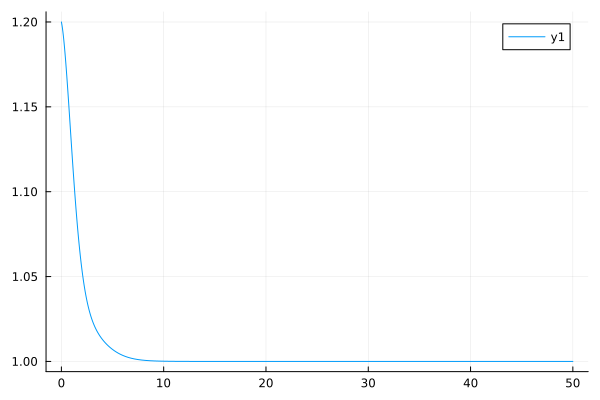

In [116]:
plot(x,T)

In [ ]:

# for be = 0.2 : -0.005 : -0.15
#     for R = 30 :  -0.5 : 20
        R = 25
        be = -0.1
        al0 = 0.1
        Ma = Mr/R
        PinPoint= []
        total = []
        writedlm("AS.dat",total)
        B0,B1 = Timemode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,al0,be,N_cheb,Ro,Co)
        global C = eigen(B0,B1)
        global val = filter(x->-0.02<imag(x)<0.1&&abs(real(x))<0.2,C.values)
        # if val == ComplexF64[]
        #     data_temp = [be R -1 -1]
        #     continue
        # end 
        for i = 1 : min(3,length(val))
            indi = []
            val_temp = val[i]
            for al = 0.1 : 0.002 : 0.7
                vec = eigvector(val[i],C.values,C.vectors)
                B0,B1 = Timemode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,al,be,N_cheb,Ro,Co)
                val0,vec0 = RQI(B0,B1,val_temp,q0=vec)
                indi = [indi;val0]
                val_temp = val0
                vec = vec0 
                open("AS.dat", "a") do io
                write(io,"al = $al,eig = $val0\n")
                end
            end
            if i == 1
                total = indi
            else
                total = [total indi]
            end
        end
        for i = 1 : size(total,2)
            d2 = diff1(real(total[:,i]),0.002)
            for j = 1 : length(d2)-1
                if d2[j] * d2[j+1] < 0 && abs(d2[j+1])<0.01
                    PinPoint = [PinPoint;total[j,i]]
                end
            end
        end
        # if PinPoint == []
        #     data_temp = [be R -1 -1]
        # else
        #     data_temp = [be R real(PinPoint[findmax(imag(PinPoint))[2],1]) imag(PinPoint[findmax(imag(PinPoint))[2],1])]
        # end
        # data_all = [data_all;data_temp]
        # writedlm("dataall.dat",data_all)
#     end
# end

In [88]:
d2 = diff1(real(total[:,1]),0.002)
@show PinPoint

PinPoint = Any[-0.1993732315269014 + 0.001424977251600736im, -0.19937028806564702 + 0.0007625886080385452im]


2-element Vector{Any}:
  -0.1993732315269014 + 0.001424977251600736im
 -0.19937028806564702 + 0.0007625886080385452im

In [64]:
size(total,2)

3

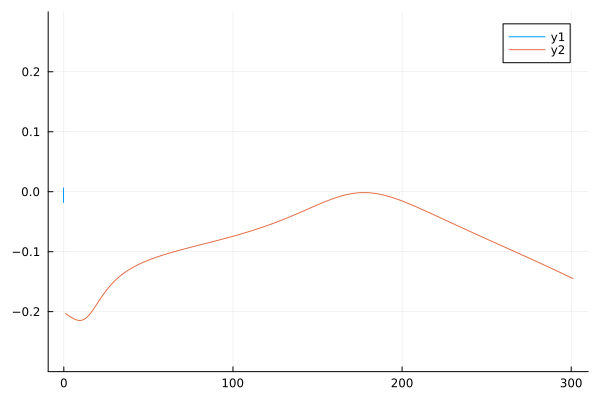

In [84]:
plot!(d2,ylims = [-0.3,0.3])

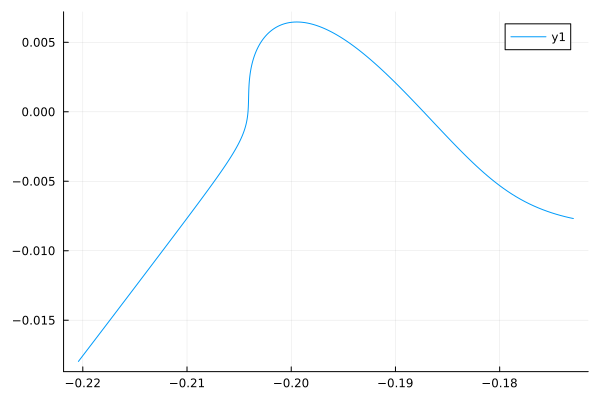

In [86]:
plot(real(total[:,1]),imag(total[:,1]))